# Mid-Major to Power Four Pitcher Projection Model

Open this notebook in VS Code or Jupyter, select a Python kernel, and choose
**Run All**. Keep the audited `.xlsx` workbook in the same folder.

Research workflow:
1. Read the audited 70-pitcher Excel workbook.
2. Pair each pitcher's qualifying mid-major season with his qualifying
   Power Four season.
3. Describe the average statistical change after moving levels.
4. Keep the 2026 transfer cohort untouched as a chronological holdout.
5. Use repeated cross-validation on 2024-2025 to compare a transparent
   average-change baseline with Ridge, Elastic Net, Random Forest, and
   Gradient Boosting models.
6. Select each target's champion by cross-validated MAE, evaluate it once on
   2026, refit on all 70 pitchers, and save a reusable prediction bundle.

Important limitation: 70 pitchers is a small modeling sample. The code uses
regularization, simple tree constraints, repeated CV, and an honest future-
season holdout to reduce overfitting, but projections should still be treated
as estimates with substantial uncertainty.

## 0. Install required packages

Run this cell once for the selected kernel. `%pip` installs into that same
kernel, which avoids the common `ModuleNotFoundError: joblib` problem.

In [1]:
%pip install -q pandas numpy scikit-learn openpyxl matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")


@dataclass(frozen=True)
class Config:
    # Leave as None to automatically find the transfer workbook beside the
    # notebook. To force a file, use Path("your_workbook.xlsx").
    data_path: Path | None = None
    output_dir: Path = Path("model_outputs")
    holdout_cohort: int = 2026
    random_seed: int = 6021
    cv_splits: int = 5
    cv_repeats: int = 3
    interval_level: float = 0.80


CFG = Config()
def find_workbook(configured_path: Path | None) -> Path:
    if configured_path is not None:
        return configured_path
    preferred = Path("Mid_Major_to_Power_4_Pitcher_Transfers_2024_2026.xlsx")
    if preferred.exists():
        return preferred
    candidates = sorted(Path.cwd().glob("*.xlsx"))
    if len(candidates) == 1:
        return candidates[0]
    if not candidates:
        raise FileNotFoundError("No .xlsx workbook was found beside this notebook.")
    raise FileNotFoundError(
        "More than one .xlsx file was found. Set Config.data_path to the correct file: "
        + ", ".join(path.name for path in candidates)
    )


DATA_PATH = find_workbook(CFG.data_path)
CFG.output_dir.mkdir(parents=True, exist_ok=True)
print(f"Workbook: {DATA_PATH.resolve()}")
print(f"Outputs:  {CFG.output_dir.resolve()}")

Workbook: /Users/henryjones/Documents/UVA MSDS/Baseball/Mid_Major_to_Power_4_Pitcher_Transfers_2024_2026.xlsx
Outputs:  /Users/henryjones/Documents/UVA MSDS/Baseball/model_outputs


## 1. Load and validate the audited workbook

The Excel sheets begin with a title and subtitle, so row 5 is the true header.
The summary sheet identifies the paired source and destination seasons. The
player-season sheet supplies the full pitching lines.

In [3]:
REQUIRED_PACKAGES = "pandas numpy scikit-learn openpyxl matplotlib seaborn joblib"


def load_workbook(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path}. Put the Excel workbook beside this file "
            "or change Config.data_path.\n"
            f"Required packages: pip install {REQUIRED_PACKAGES}"
        )

    summary = pd.read_excel(path, sheet_name="Transfer Summary", header=4)
    seasons = pd.read_excel(path, sheet_name="Player Seasons", header=4)
    summary = summary.dropna(how="all").copy()
    seasons = seasons.dropna(how="all").copy()
    return summary, seasons


summary, seasons = load_workbook(DATA_PATH)
print(f"Summary pitchers: {len(summary):,}")
print(f"Player-season rows: {len(seasons):,}")
display(summary.head())

Summary pitchers: 70
Player-season rows: 241


,Player,Origin Season,Origin School,Origin Conference,Origin IP,Power 4 Season,Power 4 School,Power 4 Conference,Power 4 IP,Transfer Cohort,P4 Entry School,P4 Entry IP
0,Bennett Flynn,2023,Davidson,Atlantic 10,56.1,2024,Notre Dame,ACC,40.0,2024,Notre Dame,40.0
1,Christian Mracna,2023,George Mason,Atlantic 10,32.0,2024,Georgia,SEC,45.2,2024,Georgia,45.2
2,Jacob Peaden,2023,Davidson,Atlantic 10,39.0,2024,Missouri,SEC,37.1,2024,Missouri,37.1
3,Jeremy Neff,2023,Richmond,Atlantic 10,48.0,2024,Virginia Tech,ACC,30.2,2024,Virginia Tech,30.2
4,Logan Koester,2023,George Washington,Atlantic 10,89.2,2024,Maryland,Big Ten,72.0,2024,Maryland,72.0


In [4]:
def validate_source_tables(summary: pd.DataFrame, seasons: pd.DataFrame) -> None:
    expected_summary = {
        "Player", "Origin Season", "Origin School", "Origin Conference",
        "Origin IP", "Power 4 Season", "Power 4 School",
        "Power 4 Conference", "Power 4 IP", "Transfer Cohort",
    }
    expected_seasons = {
        "Player ID", "Player", "Season", "School", "Conference", "Class",
        "G", "GS", "IP", "TBF", "H", "R", "ER", "HR", "BB", "HBP",
        "SO", "ERA", "WHIP", "H/9", "HR/9", "BB/9", "K/9", "K/BB",
        "K%", "BB%", "K-BB%", "Approx. Opp BA", "Transfer Cohort",
    }
    missing_summary = sorted(expected_summary - set(summary.columns))
    missing_seasons = sorted(expected_seasons - set(seasons.columns))
    if missing_summary or missing_seasons:
        raise ValueError(
            f"Missing summary columns: {missing_summary}\n"
            f"Missing season columns: {missing_seasons}"
        )
    if summary["Player"].duplicated().any():
        raise ValueError("Transfer Summary must contain one row per player.")
    if seasons.duplicated(["Player", "Season", "School"]).any():
        raise ValueError("Duplicate player-season-school rows found.")
    if (summary[["Origin IP", "Power 4 IP"]] < 10).any().any():
        raise ValueError("A qualifying source or Power Four season is below 10 IP.")
    if len(summary) < 50:
        raise ValueError("Unexpectedly small dataset; check the workbook path/version.")


validate_source_tables(summary, seasons)
print("Source-table checks passed.")

Source-table checks passed.


## 2. Create one paired modeling row per pitcher

All predictors use information available from the source season or known at
transfer time. Destination performance is never used as an input feature.
This is the most important protection against target leakage.

In [5]:
SOURCE_STATS = [
    "G", "GS", "IP", "TBF", "H", "R", "ER", "HR", "BB", "HBP", "SO",
    "ERA", "WHIP", "H/9", "HR/9", "BB/9", "K/9", "K/BB", "K%", "BB%",
    "K-BB%", "Approx. Opp BA",
]

TARGETS = [
    "ERA", "WHIP", "H/9", "HR/9", "BB/9", "K/9", "K/BB",
    "K%", "BB%", "K-BB%", "IP",
]


def prefix_columns(df: pd.DataFrame, prefix: str, keep: list[str]) -> pd.DataFrame:
    return df[keep].rename(columns={c: f"{prefix}{c}" for c in keep})


def build_paired_table(summary: pd.DataFrame, seasons: pd.DataFrame) -> pd.DataFrame:
    source_keys = summary[["Player", "Origin Season", "Origin School"]].rename(
        columns={"Origin Season": "Season", "Origin School": "School"}
    )
    dest_keys = summary[["Player", "Power 4 Season", "Power 4 School"]].rename(
        columns={"Power 4 Season": "Season", "Power 4 School": "School"}
    )

    source = source_keys.merge(
        seasons, on=["Player", "Season", "School"], how="left", validate="one_to_one"
    )
    dest = dest_keys.merge(
        seasons, on=["Player", "Season", "School"], how="left", validate="one_to_one"
    )
    if source["Player ID"].isna().any() or dest["Player ID"].isna().any():
        raise ValueError("At least one qualifying season did not match Player Seasons.")

    source_keep = ["Player ID", "Player", "Season", "School", "Conference", "Class"] + SOURCE_STATS
    dest_keep = ["Player ID", "Player", "Season", "School", "Conference"] + SOURCE_STATS
    source = prefix_columns(source, "source_", source_keep)
    dest = prefix_columns(dest, "dest_", dest_keep)

    paired = summary.merge(
        source,
        left_on=["Player", "Origin Season", "Origin School"],
        right_on=["source_Player", "source_Season", "source_School"],
        validate="one_to_one",
    ).merge(
        dest,
        left_on=["Player", "Power 4 Season", "Power 4 School"],
        right_on=["dest_Player", "dest_Season", "dest_School"],
        validate="one_to_one",
    )

    paired["source_start_rate"] = paired["source_GS"] / paired["source_G"].replace(0, np.nan)
    paired["source_so_to_bb"] = paired["source_SO"] / paired["source_BB"].replace(0, np.nan)
    paired["year_gap"] = paired["Power 4 Season"] - paired["Origin Season"]
    paired["source_ip_per_game"] = paired["source_IP"] / paired["source_G"].replace(0, np.nan)

    if len(paired) != len(summary):
        raise ValueError("Pairing changed the number of pitchers.")
    return paired


paired = build_paired_table(summary, seasons)
paired.to_csv(CFG.output_dir / "paired_transfer_dataset.csv", index=False)
print(f"Paired modeling rows: {len(paired):,}")
display(paired[[
    "Player", "Origin School", "Power 4 School", "Transfer Cohort",
    "source_IP", "dest_IP", "source_K%", "dest_K%",
]].head())

Paired modeling rows: 70


,Player,Origin School,Power 4 School,Transfer Cohort,source_IP,dest_IP,source_K%,dest_K%
0,Bennett Flynn,Davidson,Notre Dame,2024,56.1,40.0,0.329317,0.288043
1,Christian Mracna,George Mason,Georgia,2024,32.0,45.2,0.248276,0.336406
2,Jacob Peaden,Davidson,Missouri,2024,39.0,37.1,0.175610,0.177419
3,Jeremy Neff,Richmond,Virginia Tech,2024,48.0,30.2,0.228972,0.177632
4,Logan Koester,George Washington,Maryland,2024,89.2,72.0,0.131841,0.119048


## 3. How do statistics change on average?

The mean change answers the descriptive question. The median is included
because a few very large improvements or declines can distort the mean.
Percentage change is not reported when a source value can be zero.

In [6]:
def summarize_changes(df: pd.DataFrame, targets: list[str]) -> pd.DataFrame:
    rows = []
    for stat in targets:
        source_col, dest_col = f"source_{stat}", f"dest_{stat}"
        valid = df[[source_col, dest_col]].dropna()
        change = valid[dest_col] - valid[source_col]
        rows.append({
            "stat": stat,
            "n": len(valid),
            "source_mean": valid[source_col].mean(),
            "power4_mean": valid[dest_col].mean(),
            "mean_change": change.mean(),
            "median_change": change.median(),
            "change_sd": change.std(ddof=1),
            "pct_improved": np.nan if stat in {"IP"} else (
                (change < 0).mean() if stat in {"ERA", "WHIP", "H/9", "HR/9", "BB/9", "BB%"}
                else (change > 0).mean()
            ),
        })
    return pd.DataFrame(rows)


average_changes = summarize_changes(paired, TARGETS)
average_changes.to_csv(CFG.output_dir / "average_stat_changes.csv", index=False)
display(average_changes.round(4))

,stat,n,source_mean,power4_mean,mean_change,median_change,change_sd,pct_improved
0,ERA,70,4.7990,5.2366,0.4376,0.5816,2.0671,0.3571
1,WHIP,70,1.4361,1.4864,0.0503,0.0055,0.4167,0.4714
2,H/9,70,8.9253,8.9083,-0.0170,0.1108,2.8532,0.5000
3,HR/9,70,1.0289,1.3519,0.3230,0.2425,0.9719,0.3286
4,BB/9,70,3.9993,4.4688,0.4696,0.5315,2.1000,0.3571
5,K/9,70,9.2026,9.1724,-0.0302,0.3055,2.6677,0.5286
6,K/BB,70,2.6074,2.5965,-0.0109,-0.2088,2.1144,0.4286
7,K%,70,0.2282,0.2255,-0.0027,0.0022,0.0710,0.5429
8,BB%,70,0.0976,0.1074,0.0098,0.0118,0.0448,0.3714
9,K-BB%,70,0.1306,0.1181,-0.0125,-0.0110,0.0925,0.4571


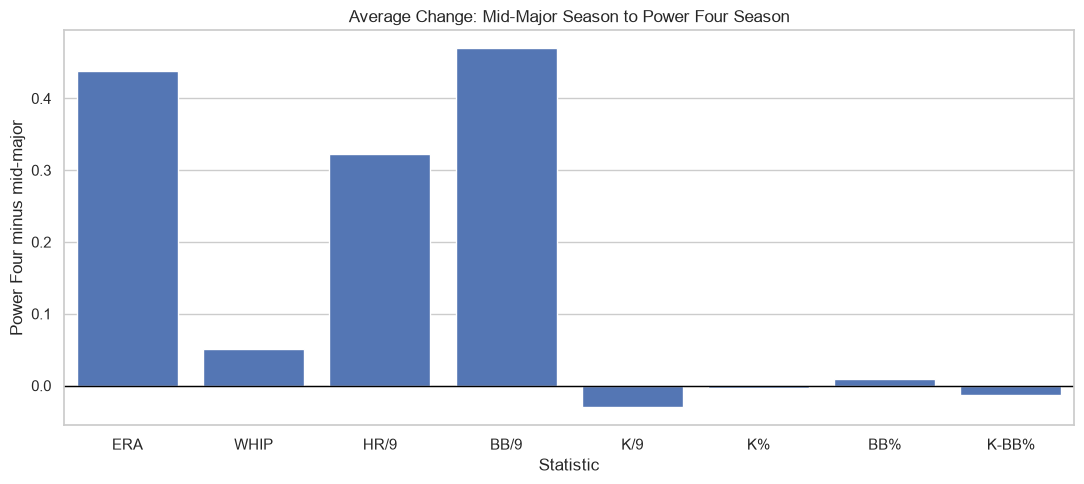

In [7]:
plot_data = average_changes[average_changes["stat"].isin(
    ["ERA", "WHIP", "HR/9", "BB/9", "K/9", "K%", "BB%", "K-BB%"]
)].copy()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_data, x="stat", y="mean_change", color="#4472C4", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Average Change: Mid-Major Season to Power Four Season",
       xlabel="Statistic", ylabel="Power Four minus mid-major")
plt.tight_layout()
plt.savefig(CFG.output_dir / "average_stat_changes.png", dpi=200)
plt.show()

## 4. Features and candidate models

The models intentionally use a modest feature set because the sample has only
70 pitchers. The preprocessing pipeline learns imputations, scaling, and
categorical encoding inside each training fold, preventing leakage.

In [8]:
NUMERIC_FEATURES = [
    "source_G", "source_GS", "source_IP", "source_TBF",
    "source_start_rate", "source_ip_per_game",
    "source_ERA", "source_WHIP", "source_H/9", "source_HR/9",
    "source_BB/9", "source_K/9", "source_K/BB", "source_K%",
    "source_BB%", "source_K-BB%", "source_Approx. Opp BA",
    "year_gap",
]
CATEGORICAL_FEATURES = [
    "Origin Conference", "Power 4 Conference", "source_Class",
]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


def make_preprocessor() -> ColumnTransformer:
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("numeric", numeric, NUMERIC_FEATURES),
        ("categorical", categorical, CATEGORICAL_FEATURES),
    ])


def make_models(seed: int) -> dict[str, Pipeline]:
    return {
        "ridge": Pipeline([
            ("prep", make_preprocessor()),
            ("model", Ridge(alpha=10.0)),
        ]),
        "elastic_net": Pipeline([
            ("prep", make_preprocessor()),
            ("model", ElasticNet(alpha=0.05, l1_ratio=0.25, max_iter=50_000)),
        ]),
        "random_forest": Pipeline([
            ("prep", make_preprocessor()),
            ("model", RandomForestRegressor(
                n_estimators=200, max_depth=5, min_samples_leaf=4,
                max_features=0.65, random_state=seed, n_jobs=-1,
            )),
        ]),
        "gradient_boosting": Pipeline([
            ("prep", make_preprocessor()),
            ("model", GradientBoostingRegressor(
                n_estimators=150, learning_rate=0.04, max_depth=2,
                min_samples_leaf=5, loss="huber", random_state=seed,
            )),
        ]),
    }


def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
    }

## 5. Repeated cross-validation on 2024–2025 only

The average-change baseline predicts:

`new Power Four stat = source stat + average training-fold change`

It is a serious benchmark, not a throwaway. A machine-learning model becomes
champion only if it beats that simple translation in repeated CV.

In [9]:
development = paired[paired["Transfer Cohort"] < CFG.holdout_cohort].reset_index(drop=True)
holdout = paired[paired["Transfer Cohort"] == CFG.holdout_cohort].reset_index(drop=True)

if development.empty or holdout.empty:
    raise ValueError("Chronological split created an empty development or holdout set.")
if development["Transfer Cohort"].max() >= holdout["Transfer Cohort"].min():
    raise ValueError("The holdout must be later than every development cohort.")

print(f"Development rows (2024-2025): {len(development)}")
print(f"Untouched 2026 holdout rows:    {len(holdout)}")


def repeated_cv_compare(
    data: pd.DataFrame,
    target: str,
    seed: int,
) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    target_col = f"dest_{target}"
    source_col = f"source_{target}"
    use = data.dropna(subset=[target_col, source_col]).reset_index(drop=True)
    X, y = use[FEATURES], use[target_col].to_numpy(dtype=float)
    source_values = use[source_col].to_numpy(dtype=float)

    cv = RepeatedKFold(
        n_splits=CFG.cv_splits,
        n_repeats=CFG.cv_repeats,
        random_state=seed,
    )
    models = make_models(seed)
    errors = {"average_change": []} | {name: [] for name in models}
    residuals = {name: [] for name in errors}

    for train_idx, valid_idx in cv.split(X):
        y_train, y_valid = y[train_idx], y[valid_idx]

        avg_delta = np.mean(y_train - source_values[train_idx])
        baseline_pred = source_values[valid_idx] + avg_delta
        errors["average_change"].append(mean_absolute_error(y_valid, baseline_pred))
        residuals["average_change"].extend((y_valid - baseline_pred).tolist())

        for name, template in models.items():
            model = clone(template)
            model.fit(X.iloc[train_idx], y_train)
            pred = model.predict(X.iloc[valid_idx])
            errors[name].append(mean_absolute_error(y_valid, pred))
            residuals[name].extend((y_valid - pred).tolist())

    rows = []
    for name, fold_mae in errors.items():
        rows.append({
            "target": target,
            "model": name,
            "cv_mae_mean": np.mean(fold_mae),
            "cv_mae_sd": np.std(fold_mae, ddof=1),
            "cv_folds": len(fold_mae),
        })
    return pd.DataFrame(rows).sort_values("cv_mae_mean"), {
        name: np.asarray(values) for name, values in residuals.items()
    }


cv_tables = []
cv_residuals = {}
for target in TARGETS:
    scores, residuals = repeated_cv_compare(development, target, CFG.random_seed)
    cv_tables.append(scores)
    cv_residuals[target] = residuals

cv_results = pd.concat(cv_tables, ignore_index=True)
champions = (
    cv_results.sort_values(["target", "cv_mae_mean"])
    .groupby("target", as_index=False)
    .first()[["target", "model", "cv_mae_mean", "cv_mae_sd"]]
    .rename(columns={"model": "champion"})
)
cv_results.to_csv(CFG.output_dir / "cross_validation_results.csv", index=False)
display(champions.round(4))

Development rows (2024-2025): 50
Untouched 2026 holdout rows:    20


,target,champion,cv_mae_mean,cv_mae_sd
0,BB%,elastic_net,0.0333,0.0129
1,BB/9,random_forest,1.5152,0.5697
2,ERA,random_forest,1.2038,0.1882
3,H/9,random_forest,1.7406,0.3929
4,HR/9,random_forest,0.5657,0.1139
5,IP,ridge,15.5626,3.1971
6,K%,elastic_net,0.0521,0.0132
7,K-BB%,elastic_net,0.0672,0.0257
8,K/9,random_forest,2.0849,0.4638
9,K/BB,average_change,1.3476,0.6774


## 6. One-time evaluation on the 2026 holdout

The holdout does not choose the champion. It estimates how the already-chosen
model performs on a later transfer cohort.

In [10]:
def fit_predict_named_model(
    model_name: str,
    train: pd.DataFrame,
    test: pd.DataFrame,
    target: str,
    seed: int,
):
    target_col, source_col = f"dest_{target}", f"source_{target}"
    train_use = train.dropna(subset=[target_col, source_col]).copy()
    test_use = test.dropna(subset=[target_col, source_col]).copy()

    if model_name == "average_change":
        delta = (train_use[target_col] - train_use[source_col]).mean()
        pred = test_use[source_col].to_numpy() + delta
        fitted = {"type": "average_change", "delta": float(delta)}
    else:
        fitted = clone(make_models(seed)[model_name])
        fitted.fit(train_use[FEATURES], train_use[target_col])
        pred = fitted.predict(test_use[FEATURES])
    return fitted, test_use, np.asarray(pred)


holdout_rows = []
holdout_predictions = []
for row in champions.itertuples(index=False):
    fitted, test_use, pred = fit_predict_named_model(
        row.champion, development, holdout, row.target, CFG.random_seed
    )
    y_true = test_use[f"dest_{row.target}"].to_numpy()
    result = metrics(y_true, pred)
    holdout_rows.append({
        "target": row.target, "champion": row.champion,
        "n_holdout": len(test_use), **result,
    })
    holdout_predictions.extend(pd.DataFrame({
        "Player": test_use["Player"], "target": row.target,
        "actual": y_true, "predicted": pred,
        "error": y_true - pred,
    }).to_dict("records"))

holdout_results = pd.DataFrame(holdout_rows)
holdout_results.to_csv(CFG.output_dir / "holdout_2026_results.csv", index=False)
pd.DataFrame(holdout_predictions).to_csv(
    CFG.output_dir / "holdout_2026_predictions.csv", index=False
)
display(holdout_results.round(4))

,target,champion,n_holdout,mae,rmse,r2
0,BB%,elastic_net,20,0.0220,0.0279,-0.0199
1,BB/9,random_forest,20,1.1154,1.4195,-0.1189
2,ERA,random_forest,20,1.1774,1.8572,-0.0911
3,H/9,random_forest,20,1.9040,2.3068,-0.1961
4,HR/9,random_forest,20,0.6685,0.9605,-0.2220
5,IP,ridge,20,13.3685,15.8910,-0.0543
6,K%,elastic_net,20,0.0360,0.0471,-0.0076
7,K-BB%,elastic_net,20,0.0419,0.0507,-0.1371
8,K/9,random_forest,20,1.2253,1.6965,0.2604
9,K/BB,average_change,20,0.8497,1.1117,-2.7533


## 7. Fit final models on all 70 pitchers and estimate uncertainty

Intervals use the empirical distribution of repeated-CV residuals from the
development period. They are useful prediction ranges, but with this small
sample they should not be interpreted as guaranteed formal coverage.

In [11]:
final_bundle = {
    "config": {
        "holdout_cohort": CFG.holdout_cohort,
        "random_seed": CFG.random_seed,
        "interval_level": CFG.interval_level,
    },
    "features": FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "targets": TARGETS,
    "models": {},
}

alpha = 1 - CFG.interval_level
for row in champions.itertuples(index=False):
    target = row.target
    target_col, source_col = f"dest_{target}", f"source_{target}"
    use = paired.dropna(subset=[target_col, source_col]).copy()

    if row.champion == "average_change":
        fitted = {
            "type": "average_change",
            "delta": float((use[target_col] - use[source_col]).mean()),
        }
    else:
        fitted = clone(make_models(CFG.random_seed)[row.champion])
        fitted.fit(use[FEATURES], use[target_col])

    residual = cv_residuals[target][row.champion]
    final_bundle["models"][target] = {
        "champion": row.champion,
        "fitted": fitted,
        "residual_low": float(np.quantile(residual, alpha / 2)),
        "residual_high": float(np.quantile(residual, 1 - alpha / 2)),
    }

joblib.dump(final_bundle, CFG.output_dir / "power4_pitcher_model_bundle.joblib")
print("Saved final model bundle.")

Saved final model bundle.


## 8. Model interpretation

Permutation importance measures how much each feature matters to prediction
after the final model is fitted. Treat it as descriptive because it is based
on the full small sample. Correlated statistics can divide importance.

In [12]:
importance_rows = []
for target, details in final_bundle["models"].items():
    if details["champion"] == "average_change":
        importance_rows.append({
            "target": target, "feature": f"source_{target}",
            "importance_mean": np.nan, "importance_sd": np.nan,
            "note": "Average-change baseline; source version of target is the predictor.",
        })
        continue

    use = paired.dropna(subset=[f"dest_{target}"]).copy()
    result = permutation_importance(
        details["fitted"], use[FEATURES], use[f"dest_{target}"],
        scoring="neg_mean_absolute_error", n_repeats=10,
        random_state=CFG.random_seed, n_jobs=-1,
    )
    for feature, mean, sd in zip(FEATURES, result.importances_mean, result.importances_std):
        importance_rows.append({
            "target": target, "feature": feature,
            "importance_mean": mean, "importance_sd": sd, "note": "",
        })

importance = pd.DataFrame(importance_rows)
importance.to_csv(CFG.output_dir / "permutation_feature_importance.csv", index=False)
display(
    importance.sort_values(["target", "importance_mean"], ascending=[True, False])
    .groupby("target").head(5).round(4)
)

,target,feature,importance_mean,importance_sd,note
5,BB%,source_ip_per_game,0.0007,0.0002,
17,BB%,year_gap,0.0001,0.0001,
14,BB%,source_BB%,0.0001,0.0000,
0,BB%,source_G,0.0000,0.0000,
1,BB%,source_GS,0.0000,0.0000,
35,BB/9,source_BB%,0.1566,0.0302,
24,BB/9,source_TBF,0.0949,0.0097,
23,BB/9,source_IP,0.0922,0.0096,
39,BB/9,Origin Conference,0.0668,0.0229,
31,BB/9,source_BB/9,0.0567,0.0152,


## 9. Project new pitchers

Enter one row per transfer candidate using his mid-major statistics. Rates
must use the same units as the workbook: percentages are decimals, so 28%
is entered as `0.28`. Destination conference should be known or set to the
most plausible landing conference.

In [13]:
LOWER_IS_BOUNDED_ZERO = {
    "ERA", "WHIP", "H/9", "HR/9", "BB/9", "K/9", "K/BB", "IP"
}
PERCENT_TARGETS = {"K%", "BB%", "K-BB%"}


def clip_target(values: np.ndarray, target: str) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    if target in LOWER_IS_BOUNDED_ZERO:
        return np.maximum(values, 0)
    if target in PERCENT_TARGETS:
        # K-BB% can theoretically be negative.
        low = -1 if target == "K-BB%" else 0
        return np.clip(values, low, 1)
    return values


def project_pitchers(new_pitchers: pd.DataFrame, bundle: dict) -> pd.DataFrame:
    missing = sorted(set(bundle["features"]) - set(new_pitchers.columns))
    if missing:
        raise ValueError(f"New-pitcher table is missing features: {missing}")

    output = new_pitchers.copy()
    for target, details in bundle["models"].items():
        if details["champion"] == "average_change":
            source_col = f"source_{target}"
            if source_col not in output:
                raise ValueError(f"Baseline for {target} requires {source_col}.")
            pred = output[source_col].to_numpy(dtype=float) + details["fitted"]["delta"]
        else:
            pred = details["fitted"].predict(output[bundle["features"]])

        low = pred + details["residual_low"]
        high = pred + details["residual_high"]
        output[f"projected_{target}"] = clip_target(pred, target)
        output[f"projected_{target}_low"] = clip_target(low, target)
        output[f"projected_{target}_high"] = clip_target(high, target)
    return output


# Example player. Replace these values or add more rows.
new_pitchers = pd.DataFrame([{
    "Player": "Example Transfer",
    "source_G": 15,
    "source_GS": 12,
    "source_IP": 75.0,
    "source_TBF": 310,
    "source_start_rate": 12 / 15,
    "source_ip_per_game": 75 / 15,
    "source_ERA": 3.60,
    "source_WHIP": 1.22,
    "source_H/9": 8.10,
    "source_HR/9": 0.72,
    "source_BB/9": 2.90,
    "source_K/9": 10.40,
    "source_K/BB": 3.59,
    "source_K%": 0.280,
    "source_BB%": 0.078,
    "source_K-BB%": 0.202,
    "source_Approx. Opp BA": 0.235,
    "year_gap": 1,
    "Origin Conference": "CAA",
    "Power 4 Conference": "ACC",
    "source_Class": "Jr",
}])

projections = project_pitchers(new_pitchers, final_bundle)
projections.to_csv(CFG.output_dir / "example_new_pitcher_projection.csv", index=False)
display(projections.filter(regex="Player|projected_" ).round(3))

,Player,projected_BB%,projected_BB%_low,projected_BB%_high,projected_BB/9,projected_BB/9_low,projected_BB/9_high,projected_ERA,projected_ERA_low,projected_ERA_high,...,projected_K-BB%_high,projected_K/9,projected_K/9_low,projected_K/9_high,projected_K/BB,projected_K/BB_low,projected_K/BB_high,projected_WHIP,projected_WHIP_low,projected_WHIP_high
0,Example Transfer,0.105,0.06,0.154,3.652,1.539,5.753,4.44,2.399,6.474,...,0.227,9.339,5.596,12.949,3.579,1.705,5.05,1.379,0.947,1.847


## 10. Files created

- `paired_transfer_dataset.csv`: one source/destination pair per pitcher
- `average_stat_changes.csv` and `.png`: descriptive transition results
- `cross_validation_results.csv`: repeated-CV model comparison
- `holdout_2026_results.csv`: honest later-cohort performance
- `holdout_2026_predictions.csv`: pitcher-level holdout errors
- `permutation_feature_importance.csv`: model interpretation
- `power4_pitcher_model_bundle.joblib`: reusable fitted models
- `example_new_pitcher_projection.csv`: example output format

In [14]:
run_summary = {
    "pitchers": int(len(paired)),
    "development_rows": int(len(development)),
    "holdout_rows": int(len(holdout)),
    "targets": TARGETS,
    "champions": champions.set_index("target")["champion"].to_dict(),
}
(CFG.output_dir / "run_summary.json").write_text(json.dumps(run_summary, indent=2))
print(json.dumps(run_summary, indent=2))
print("Modeling workflow completed successfully.")

{
  "pitchers": 70,
  "development_rows": 50,
  "holdout_rows": 20,
  "targets": [
    "ERA",
    "WHIP",
    "H/9",
    "HR/9",
    "BB/9",
    "K/9",
    "K/BB",
    "K%",
    "BB%",
    "K-BB%",
    "IP"
  ],
  "champions": {
    "BB%": "elastic_net",
    "BB/9": "random_forest",
    "ERA": "random_forest",
    "H/9": "random_forest",
    "HR/9": "random_forest",
    "IP": "ridge",
    "K%": "elastic_net",
    "K-BB%": "elastic_net",
    "K/9": "random_forest",
    "K/BB": "average_change",
    "WHIP": "random_forest"
  }
}
Modeling workflow completed successfully.
